<a href="https://colab.research.google.com/github/anastasiavorobeva029-commits/Data-Science-Projects/blob/main/EDA_%D0%BF%D0%BE%D0%BA%D0%B5%D0%BC%D0%BE%D0%BD%D1%8B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import requests, zipfile, io  # работает с архивами
import matplotlib.pyplot as plt  # работает с графиками и диаграммами
import seaborn as sns  # работает с графиками и диаграммами
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix

In [ ]:
df = pd.read_csv('archive.zip')

In [ ]:
df.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


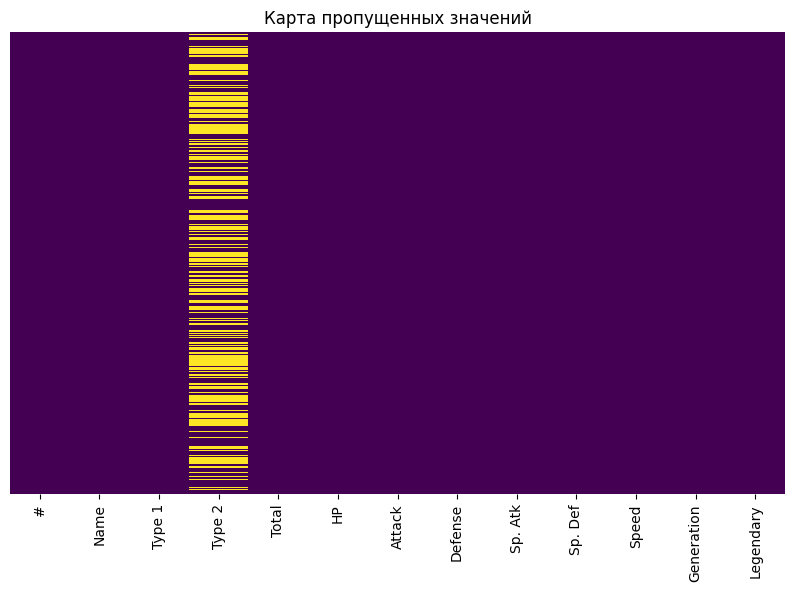

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Карта пропущенных значений')
plt.show()

In [ ]:
data = df.groupby('Type 1')['Name'].agg(count='count').reset_index().sort_values(by='Type 1')

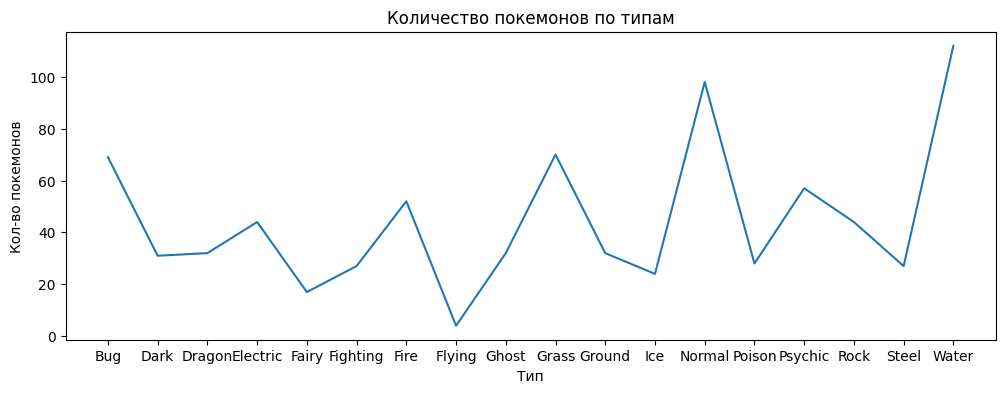

In [ ]:
plt.figure(figsize=(12, 4))

plt.plot(data['Type 1'], data['count'])

plt.title('Количество покемонов по типам')
plt.xlabel('Тип')
plt.ylabel('Кол-во покемонов')

plt.show()

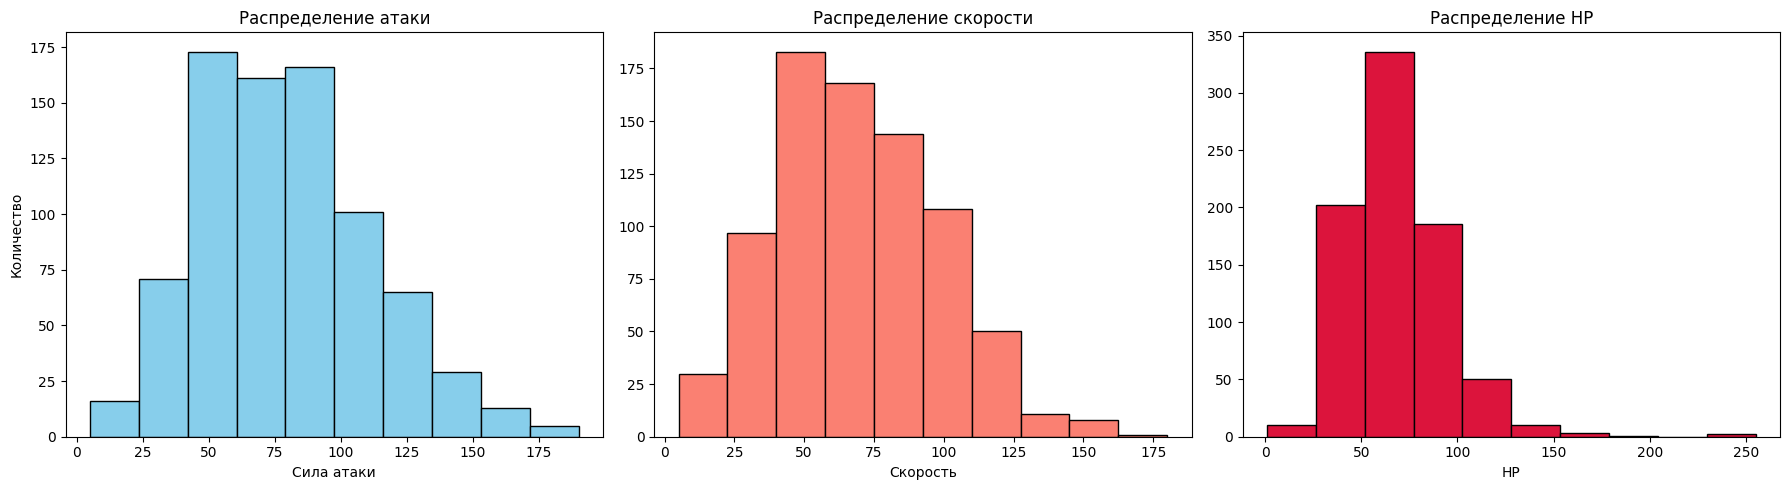

In [ ]:

# Создаем сетку: 1 строка, 3 столбца
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. График Атаки (Голубой)
axes[0].hist(df['Attack'], bins=10, color='skyblue', edgecolor='black')
axes[0].set_title('Распределение атаки')
axes[0].set_xlabel('Сила атаки')
axes[0].set_ylabel('Количество')

# 2. График Скорости (Коралловый)
axes[1].hist(df['Speed'], bins=10, color='salmon', edgecolor='black')
axes[1].set_title('Распределение скорости')
axes[1].set_xlabel('Скорость')

# 3. График Защиты (Зеленый)
axes[2].hist(df['HP'], bins=10, color='crimson', edgecolor='black')
axes[2].set_title('Распределение HP')
axes[2].set_xlabel('HP')

# Улучшаем расположение элементов
plt.tight_layout()
plt.show()

In [ ]:
# самый сильный покемон

best_all = df.loc[df['Total'] == df['Total'].max()]
best_all

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
163,150,MewtwoMega Mewtwo X,Psychic,Fighting,780,106,190,100,154,100,130,1,True
164,150,MewtwoMega Mewtwo Y,Psychic,NaN,780,106,150,70,194,120,140,1,True
426,384,RayquazaMega Rayquaza,Dragon,Flying,780,105,180,100,180,100,115,3,True


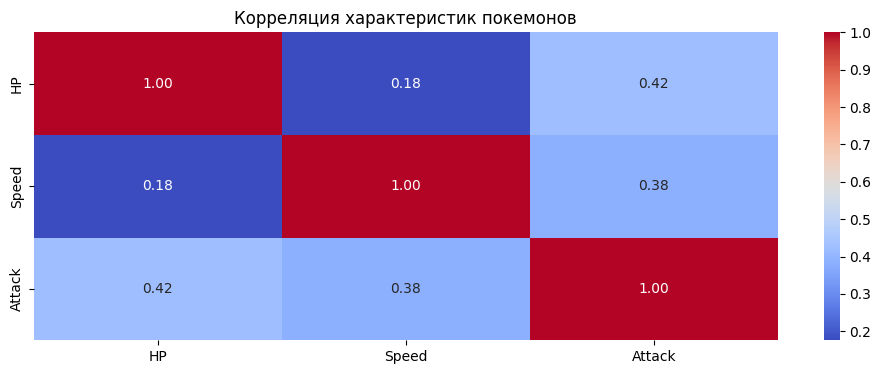

In [ ]:
# проверим корреляцию покемонов: правда ли, что более сильные покемоны более медленные, и более сильные покемоны с большим количеством HP

numeric_df = df[["HP", "Speed", "Attack"]]

plt.figure(figsize=(12,4))

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляция характеристик покемонов')
plt.show()

**Гипотеза "более сильные покемоны более медленные" не верна:**
speed/attack 0.38 - то есть, наоборот - более сильные покемоны более быстрые

**Гипотеза "более сильные покемоны с большим количеством HP" верна:**
attack/HP 0.42 - более сильные покемоны имеют большое количество HP
```
# Выбран кодовый формат
```



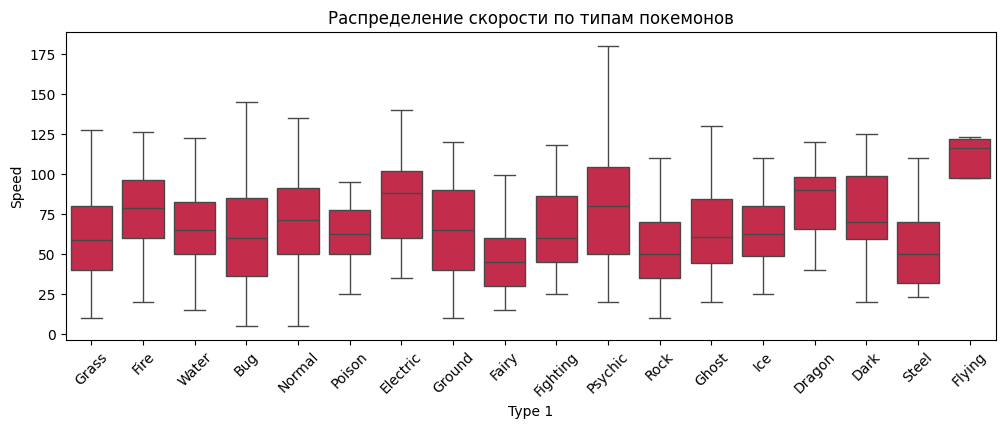

In [ ]:
# правда ли что скорость покемонов зависит от их типа

plt.figure(figsize=(12,4))
sns.boxplot(data=df, x='Type 1', y='Speed', showfliers=False, color = 'crimson')
plt.xticks(rotation=45)
plt.title('Распределение скорости по типам покемонов')
plt.show()

**1. Скорость по типам**
1. Самые быстрые: Тип Flying выделяется самым высоким медианным значением скорости. Также высокими показателями обладают типы Electric и Dragon.

2. Самые медленные: Тип Fairy и Steel имеют одни из самых низких медианных значений скорости.

3. Рекордсмены: У типа Psychic наблюдается самый длинный верхний «ус» (доходящий до 180), что говорит о наличии экстремально быстрых представителей в этой группе.

**2. Чтение элементов графика**
1. Горизонтальная черта внутри ящика: Это медиана. Если она высоко (как у Flying), значит, большинство покемонов этого типа быстрые.

2. Высота малинового ящика (межквартильный размах): Показывает разброс скорости у 50% «типичных» покемонов этого типа. Например, у Bug разброс очень большой, а у Poison — довольно узкий, то есть они более однородны по скорости.

3. Вертикальные линии («усы»): Показывают диапазон минимальных и максимальных значений (исключая статистические выбросы).

**3. Интересные наблюдения**
1. Разнообразие: У типов Bug и Normal очень длинные усы, что означает огромную разницу между самыми медленными и самыми быстрыми представителями внутри одного типа.

2. Стабильность: Тип Flying имеет очень компактный ящик, расположенный высоко. Это значит, что почти все летающие покемоны стабильно быстрее большинства остальных типов.

/tmp/ipython-input-1363946329.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Legendary', y='Total', data=df, palette='Set3')


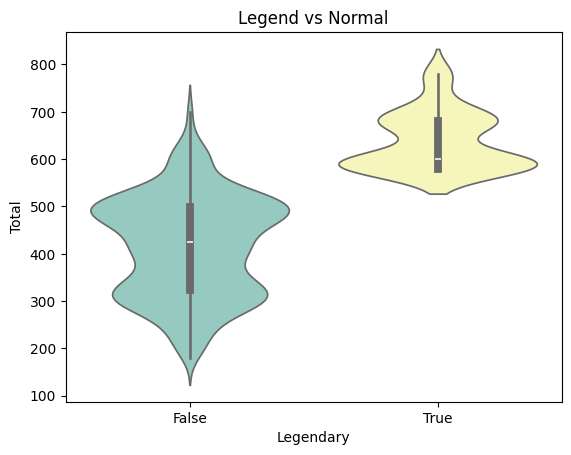

In [ ]:
# насколько легендарные покемоны сильнее обычных

sns.violinplot(x='Legendary', y='Total', data=df, palette='Set3')
plt.title('Legend vs Normal')
plt.xlabel('Legendary')
plt.ylabel('Total')
plt.show()


**Ширина «скрипки»:** Чем шире фигура в определенном месте, тем больше покемонов имеют именно такой показатель Total.

У обычных покемонов основной «пузырь» находится в районе 300–500 очков. Это «средний класс».

У легендарных покемонов распределение начинается там, где обычные почти заканчиваются — их основная масса сосредоточена в районе 600–700 очков.

**Белая точка в центре:** Это медиана. Она наглядно показывает, что средний легендарный покемон почти в два раза сильнее среднего обычного.

**Черный прямоугольник в центре:** Это межквартильный размах (те самые 50% покемонов). У легендарных он гораздо выше и компактнее — среди них почти нет «слабаков».

**Тонкие «хвосты»:** У обычных покемонов есть очень длинный хвост вниз (до 180–200). Это начальные формы эволюции (например, Magikarp).

У легендарных хвост уходит вверх за 800. Это «ультра-формы» или сильнейшие легенды вроде Mega Rayquaza или Mewtwo.

In [ ]:
# список покемонов, которые равны силе с легендарными

pseudo_legends = df[(df['Legendary'] == False) & (df['Total'] >= 600)]
pseudo_legends

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
7,6,CharizardMega Charizard X,Fire,Dragon,634,78,130,111,130,85,100,1,False
8,6,CharizardMega Charizard Y,Fire,Flying,634,78,104,78,159,115,100,1,False
12,9,BlastoiseMega Blastoise,Water,NaN,630,79,103,120,135,115,78,1,False
102,94,GengarMega Gengar,Ghost,Poison,600,60,65,80,170,95,130,1,False
137,127,PinsirMega Pinsir,Bug,Flying,600,65,155,120,65,90,105,1,False
141,130,GyaradosMega Gyarados,Water,Dark,640,95,155,109,70,130,81,1,False
154,142,AerodactylMega Aerodactyl,Rock,Flying,615,80,135,85,70,95,150,1,False
161,149,Dragonite,Dragon,Flying,600,91,134,95,100,100,80,1,False
165,151,Mew,Psychic,NaN,600,100,100,100,100,100,100,1,False


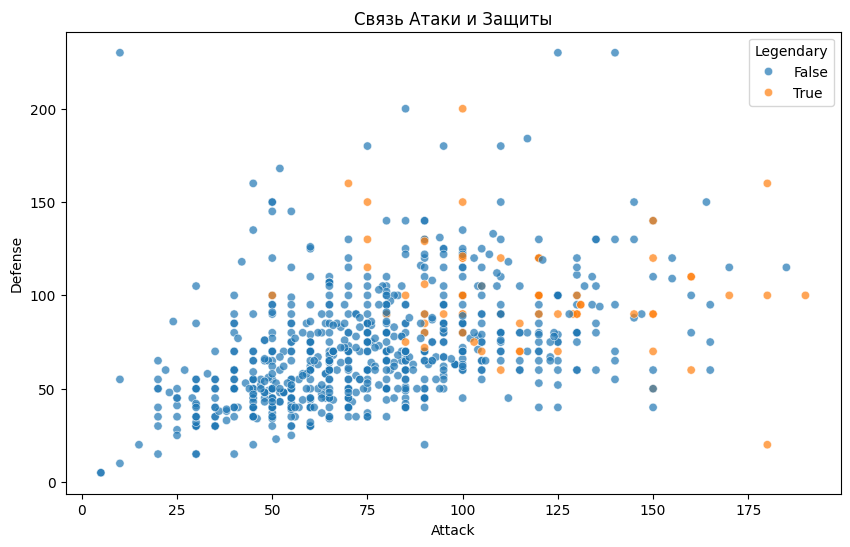

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Attack', y='Defense', hue='Legendary', data=df, alpha=0.7)
plt.title('Связь Атаки и Защиты')
plt.show()

**Танки (Верхний левый угол):** Покемоны с защитой около 200–230, но средней атакой. Интересно, что среди них есть как легендарные, так и обычные покемоны.

**Стеклянные пушки (Нижний правый угол):** Есть точка с атакой 180, но очень низкой защитой (около 20). Это явно покемон, рассчитанный на один сокрушительный удар.

**Элита (Правый верхний угол):** Оранжевые точки (легенды) кучно расположены в зоне высоких показателей (100+ атаки и 100+ защиты), подтверждая свою универсальность.

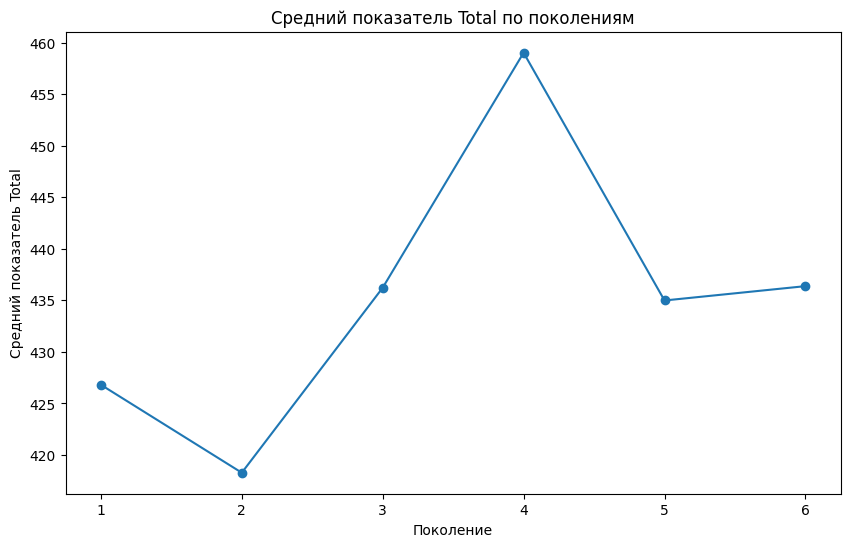

In [ ]:
df.groupby('Generation')['Total'].mean()

plt.figure(figsize=(10, 6))
plt.plot(df.groupby('Generation')['Total'].mean(), marker='o')
plt.title('Средний показатель Total по поколениям')
plt.xlabel('Поколение')
plt.ylabel('Средний показатель Total')
plt.show()